# Week 2 — Preprocessing & Baseline Models
**Models**: Logistic Regression, MLP (scikit-learn)  
**Features**: TF-IDF (unigrams + bigrams, 50,000 features)


In [27]:
import sys, os
sys.path.insert(0, 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import clean_text, get_tfidf_features, split_data
from evaluate import compute_metrics, print_report, plot_confusion_matrix

sns.set_theme(style='whitegrid')
os.makedirs('results/figures', exist_ok=True)

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load & Clean Data

In [29]:
import os
import pandas as pd

# если файла нет — создаём 30k датасет автоматически
if not os.path.exists('data/processed/reviews_30k.csv'):
    print("File not found. Creating 30k dataset...")

    df_full = pd.read_csv('Reviews.csv')

    df_30k = df_full.sample(n=min(30000, len(df_full)), random_state=42)

    os.makedirs('data/processed', exist_ok=True)
    df_30k.to_csv('data/processed/reviews_30k.csv', index=False)

    print("30k dataset created and saved.")

In [30]:
print('Cleaning text data...')
df_30k['clean_text'] = df_30k['Text'].apply(clean_text)
print('Text data cleaned and new column "clean_text" created.')

Cleaning text data...
Text data cleaned and new column "clean_text" created.


In [31]:
# Convert 'Score' into a binary sentiment label: 1 for positive (Score >= 4), 0 otherwise
df_30k['sentiment_label'] = df_30k['Score'].apply(lambda x: 1 if x >= 4 else 0)
print('Binary sentiment label "sentiment_label" created based on "Score" column.')
# Display the value counts for the new sentiment label
print(df_30k['sentiment_label'].value_counts())

Binary sentiment label "sentiment_label" created based on "Score" column.
sentiment_label
1    23039
0     6961
Name: count, dtype: int64


## 2. Train / Validation / Test Split (70 / 15 / 15)

In [32]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df_30k, label_col='sentiment_label')
print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

# Verify label balance in each split
for split_name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    pos_pct = round(y.mean() * 100, 1)
    print(f'  {split_name}: {pos_pct}% positive')

Split sizes  →  train: 21,000  val: 4,500  test: 4,500
Train: 21,000  Val: 4,500  Test: 4,500
  train: 76.8% positive
  val: 76.8% positive
  test: 76.8% positive


## 3. TF-IDF Feature Extraction

In [33]:
print('Building TF-IDF features ...')
X_train_tfidf, X_val_tfidf, X_test_tfidf, vectoriser = get_tfidf_features(
    X_train, X_val, X_test, max_features=50_000, ngram_range=(1, 2)
)
print(f'Feature matrix shape: {X_train_tfidf.shape}')

Building TF-IDF features ...
Feature matrix shape: (21000, 50000)


## 4. Baseline 1 — Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
import time

t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', n_jobs=-1, random_state=42)
lr.fit(X_train_tfidf, y_train)
print(f'Training time: {time.time()-t0:.1f}s')

lr_val_metrics  = compute_metrics(y_val,  lr.predict(X_val_tfidf))
lr_test_metrics = compute_metrics(y_test, lr.predict(X_test_tfidf))

print('\nValidation:', lr_val_metrics)
print('Test:      ', lr_test_metrics)
print_report(y_test, lr.predict(X_test_tfidf), 'Logistic Regression')

Training time: 2.4s

Validation: {'accuracy': 0.8662, 'precision': 0.8676, 'recall': 0.9745, 'f1': 0.918}
Test:       {'accuracy': 0.866, 'precision': 0.8685, 'recall': 0.9728, 'f1': 0.9177}

Model: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.85      0.51      0.64      1044
    Positive       0.87      0.97      0.92      3456

    accuracy                           0.87      4500
   macro avg       0.86      0.74      0.78      4500
weighted avg       0.86      0.87      0.85      4500



In [35]:
plot_confusion_matrix(
    y_test, lr.predict(X_test_tfidf),
    'Logistic Regression',
    'results/figures/lr_confusion_matrix.png'
)

Confusion matrix saved: results/figures/lr_confusion_matrix.png


## 5. Baseline 2 — MLP

In [36]:
from sklearn.neural_network import MLPClassifier

t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu', solver='adam',
    alpha=1e-4, batch_size=256,
    learning_rate_init=1e-3,
    max_iter=20, early_stopping=True,
    validation_fraction=0.1, n_iter_no_change=5,
    random_state=42, verbose=True
)
mlp.fit(X_train_tfidf, y_train)
print(f'Training time: {time.time()-t0:.1f}s')

mlp_val_metrics  = compute_metrics(y_val,  mlp.predict(X_val_tfidf))
mlp_test_metrics = compute_metrics(y_test, mlp.predict(X_test_tfidf))
print('\nValidation:', mlp_val_metrics)
print('Test:      ', mlp_test_metrics)
print_report(y_test, mlp.predict(X_test_tfidf), 'MLP')

Iteration 1, loss = 0.48449661
Validation score: 0.847143
Iteration 2, loss = 0.18930051
Validation score: 0.881905
Iteration 3, loss = 0.04105486
Validation score: 0.870476
Iteration 4, loss = 0.01057417
Validation score: 0.877619
Iteration 5, loss = 0.00471038
Validation score: 0.876667
Iteration 6, loss = 0.00289463
Validation score: 0.875714
Iteration 7, loss = 0.00214692
Validation score: 0.875714
Iteration 8, loss = 0.00172213
Validation score: 0.874286
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.
Training time: 371.5s

Validation: {'accuracy': 0.8756, 'precision': 0.9149, 'recall': 0.9239, 'f1': 0.9194}
Test:       {'accuracy': 0.8791, 'precision': 0.9146, 'recall': 0.9294, 'f1': 0.9219}

Model: MLP
              precision    recall  f1-score   support

    Negative       0.75      0.71      0.73      1044
    Positive       0.91      0.93      0.92      3456

    accuracy                           0.88      4500
   macro avg       

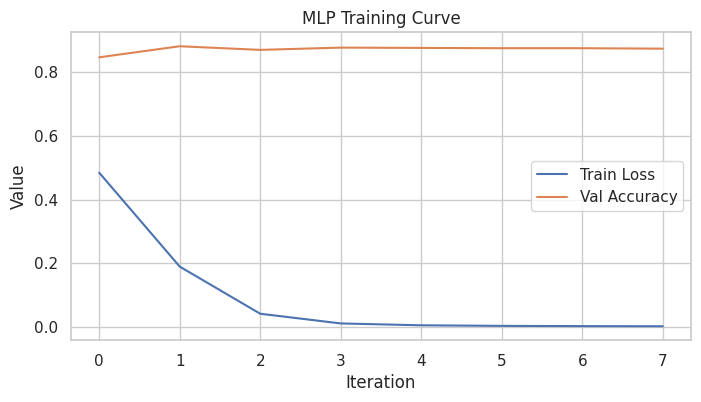

Confusion matrix saved: results/figures/mlp_confusion_matrix.png


In [37]:
# MLP training loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label='Train Loss')
if mlp.validation_scores_ is not None:
    plt.plot(mlp.validation_scores_, label='Val Accuracy')
plt.xlabel('Iteration'); plt.ylabel('Value')
plt.title('MLP Training Curve')
plt.legend()
plt.savefig('results/figures/mlp_training_curve.png', dpi=150)
plt.show()

plot_confusion_matrix(
    y_test, mlp.predict(X_test_tfidf),
    'MLP', 'results/figures/mlp_confusion_matrix.png'
)

## 6. Comparison Summary

In [38]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', **lr_test_metrics},
    {'Model': 'MLP',                 **mlp_test_metrics},
])
print(results.to_string(index=False))
results.to_csv('results/baseline_results.csv', index=False)
print('\nSaved to results/baseline_results.csv')

              Model  accuracy  precision  recall     f1
Logistic Regression    0.8660     0.8685  0.9728 0.9177
                MLP    0.8791     0.9146  0.9294 0.9219

Saved to results/baseline_results.csv


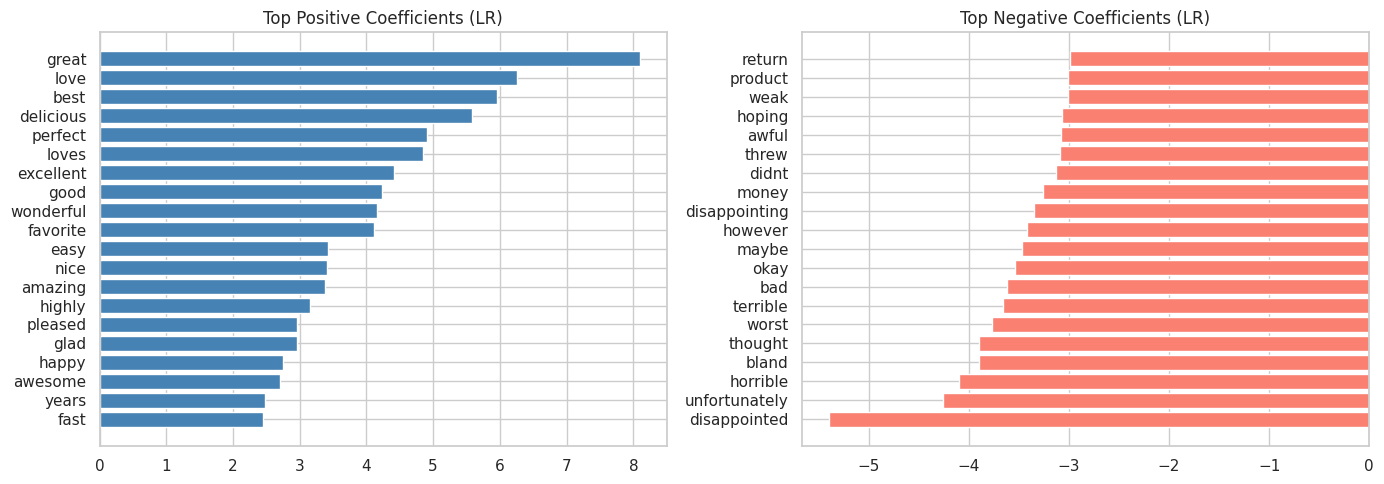

In [39]:
# Most predictive features from Logistic Regression
feature_names = vectoriser.get_feature_names_out()
coefs = lr.coef_[0]
top_pos_idx = coefs.argsort()[-20:][::-1]
top_neg_idx = coefs.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color='steelblue')
axes[0].set_title('Top Positive Coefficients (LR)')
axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx], color='salmon')
axes[1].set_title('Top Negative Coefficients (LR)')
plt.tight_layout()
plt.savefig('results/figures/lr_top_features.png', dpi=150)
plt.show()